In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os

# Load model and features
model = joblib.load('../models/best_model.pkl')
with open('../models/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

# Load data
df = pd.read_csv('../data/processed/features.csv')

# Split same way as before
test = df[df['Year'] == 2023].copy()
X_test = test[FEATURE_COLS]
y_test = test['quali_best']

preds = model.predict(X_test)
print(f"✅ Loaded {len(y_test)} test samples")

✅ Loaded 337 test samples


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print(f"MAE:  {mae:.3f} seconds")
print(f"RMSE: {rmse:.3f} seconds")
print(f"R²:   {r2:.4f}")

MAE:  1.012 seconds
RMSE: 2.125 seconds
R²:   0.9561


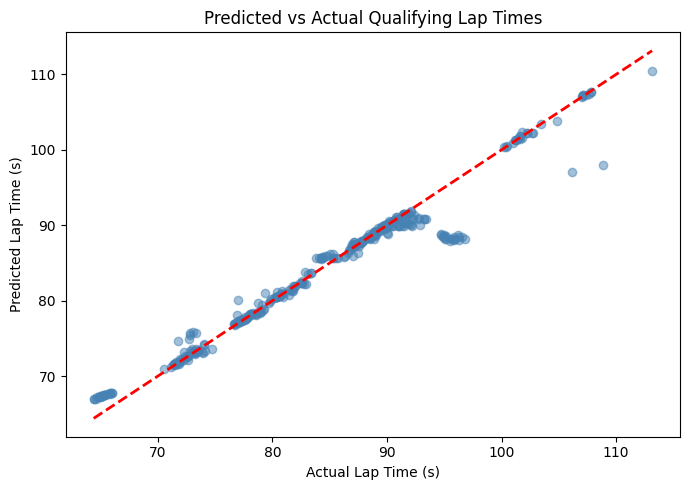

Chart saved!


In [5]:
base_dir   = os.path.abspath(os.path.join(os.getcwd(), '..'))
assets_dir = '/Users/harshiniratnakumar/Desktop/f1-quali-predictor/assets'
os.makedirs(assets_dir, exist_ok=True)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, preds, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Lap Time (s)')
plt.ylabel('Predicted Lap Time (s)')
plt.title('Predicted vs Actual Qualifying Lap Times')
plt.tight_layout()
plt.savefig(os.path.join(assets_dir, 'pred_vs_actual.png'))
plt.show()
print("Chart saved!")

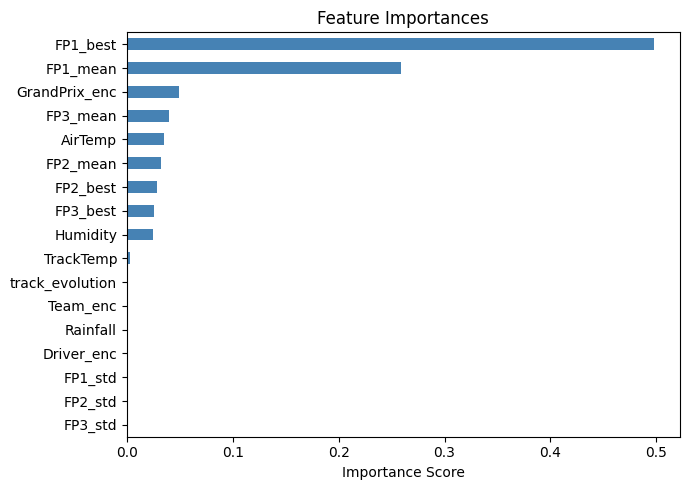

Chart saved!


In [6]:
assets_dir = '/Users/harshiniratnakumar/Desktop/f1-quali-predictor/assets'
os.makedirs(assets_dir, exist_ok=True)

importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importances.sort_values().plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(assets_dir, 'feature_importance.png'))
plt.show()
print("Chart saved!")